Acurácia média no treino (CV): 1.0000
Acurácia final no conjunto de validação: 0.9995

Matriz de confusão - Treino:
[[3299    0]
 [   0 3738]]

Matriz de confusão - Validação:
[[2929    2]
 [   1 3081]]


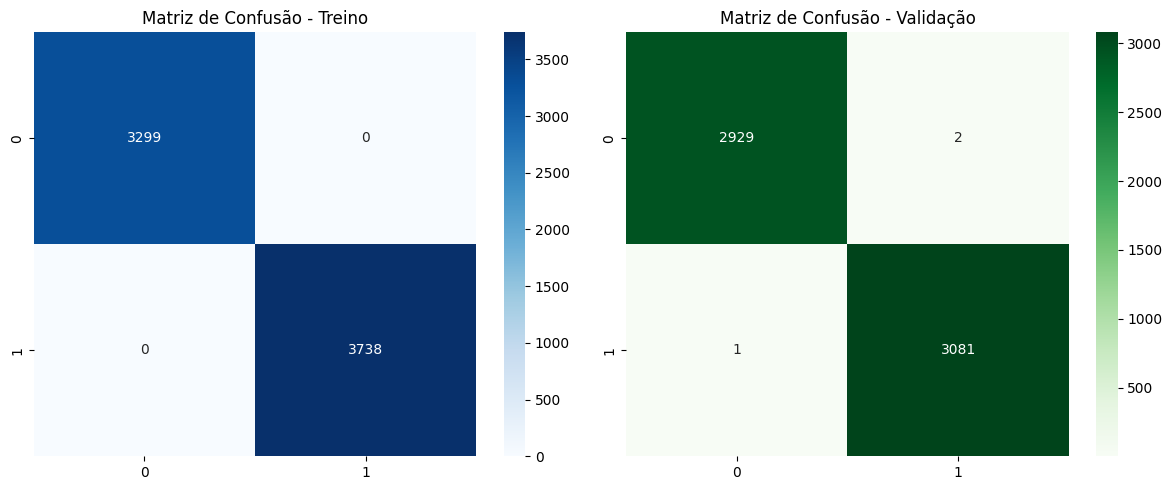

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('candles_previstos_como_1.csv', parse_dates=['datetime'])

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

treino = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
validacao = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

for df in [treino, validacao]:
    df.drop(columns=['datetime','date','close','open','low','high','volume','average','amount_stock','id_ticker','business'], inplace=True)

X_train = treino.drop(columns=['trend'])  
y_train = treino['trend']  

X_valid = validacao.drop(columns=['trend'])  
y_valid = validacao['trend'] 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

train_preds = np.zeros(len(X_train))
val_preds = np.zeros(len(X_valid))  

train_scores = []
val_scores = []

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),  
        early_stopping=False,
        random_state=42
    )

    mlp.fit(X_tr, y_tr)

    y_tr_pred = mlp.predict(X_tr)
    y_val_pred = mlp.predict(X_val)

    train_scores.append(accuracy_score(y_tr, y_tr_pred))
    val_scores.append(accuracy_score(y_val, y_val_pred))

    train_preds[train_idx] = y_tr_pred

final_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    early_stopping=False,
    random_state=42
)
final_model.fit(X_train_scaled, y_train)
val_preds = final_model.predict(X_valid_scaled)

# Resultados
print(f"Acurácia média no treino (CV): {np.mean(train_scores):.4f}")
print(f"Acurácia final no conjunto de validação: {accuracy_score(y_valid, val_preds):.4f}")

print("\nMatriz de confusão - Treino:")
print(confusion_matrix(y_train, train_preds))

print("\nMatriz de confusão - Validação:")
print(confusion_matrix(y_valid, val_preds))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_train, train_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino")
sns.heatmap(confusion_matrix(y_valid, val_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz de Confusão - Validação")

plt.tight_layout()
plt.show()


Acurácia do modelo 0 (fold): 0.5533
Acurácia do modelo 1 (fold): 0.5746
Acurácia do modelo 2 (fold): 0.5948
Acurácia do modelo 3 (fold): 0.5640
Acurácia do modelo 4 (fold): 0.5599
Acurácia do modelo 5 (fold): 0.5635
Acurácia do modelo 6 (fold): 0.5789
Acurácia do modelo 7 (fold): 0.5469
Acurácia do modelo 8 (fold): 0.5741
Acurácia média do Cross-Validation: 0.5678 ± 0.0137
Acurácia do ensemble no conjunto de teste: 0.5538


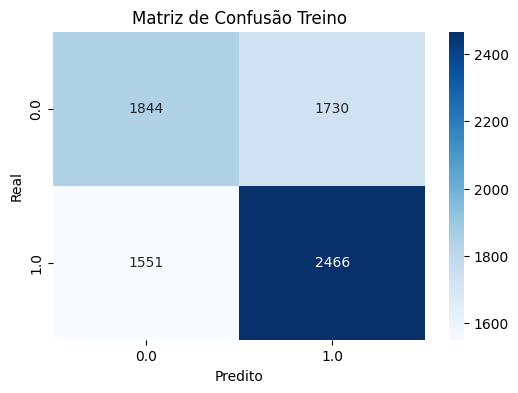

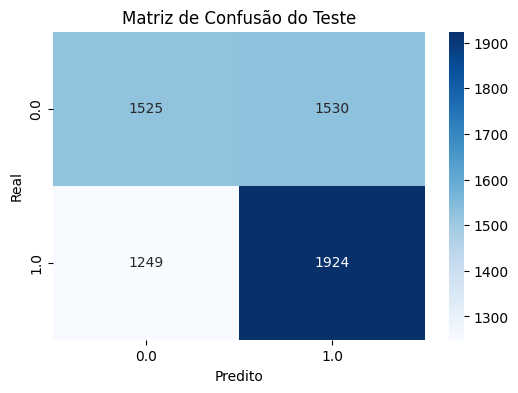

In [ ]:
cv = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

modelos_treinados = []
scores = []
y_valid_total = []
y_pred_total = []

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):                
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    modelo_clone = clone(modelo)
    modelo_clone.fit(X_fold_train, y_fold_train)
    
    y_pred = modelo_clone.predict(X_fold_val)
    score = accuracy_score(y_fold_val, y_pred)
    
    modelos_treinados.append((f'modelo_{i}', modelo_clone))
    scores.append(score)

    print(f'Acurácia do modelo {i} (fold): {score:.4f}')

    y_valid_total.extend(y_fold_val)
    y_pred_total.extend(y_pred)

# Criar ensemble com os modelos treinados
ensemble = VotingClassifier(estimators=modelos_treinados, voting='hard') 

# Treina o ensemble no conjunto completo de treino
ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_valid)
final_accuracy = accuracy_score(y_valid, y_pred_ensemble)

cm = confusion_matrix(y_valid_total, y_pred_total)

print(f'Acurácia média do Cross-Validation: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
print(f'Acurácia do ensemble no conjunto de teste: {final_accuracy:.4f}')

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0.0", "1.0"], yticklabels=["0.0", "1.0"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão Treino")
plt.show()

matriz_confusao = confusion_matrix(y_valid, y_pred_ensemble)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_valid), yticklabels=np.unique(y_valid))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Teste')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- ETAPA 1: Carregamento e separação dos dados ---
df = pd.read_csv('candles_previstos_como_1_MLP.csv', parse_dates=['datetime'])

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

treino = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
validacao = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

for df_ in [treino, validacao]:
    df_.drop(columns=['datetime', 'date', 'close', 'open', 'low', 'high', 'volume',
                      'average', 'amount_stock', 'id_ticker', 'business'], inplace=True)

X_train = treino.drop(columns=['trend'])  
y_train = treino['trend']  

X_valid = validacao.drop(columns=['trend'])  
y_valid = validacao['trend'] 

# --- ETAPA 2: Normalização ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


skf = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    early_stopping=False,
    random_state=42
)


# Validação cruzada
cv_scores = cross_val_score(mlp, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("Acurácias da Validação Cruzada:")
for i, score in enumerate(cv_scores):
    print(f"Dobra {i+1}: {score:.4f}")
print(f"Média da acurácia: {cv_scores.mean():.4f}")
print(f"Desvio padrão: {cv_scores.std():.4f}")

# --- ETAPA 4: Avaliação no conjunto de validação ---
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_valid_scaled)

acc_valid = accuracy_score(y_valid, y_pred)
matriz_confusao = confusion_matrix(y_valid, y_pred)

print(f"\nAcurácia no conjunto de teste (validação): {acc_valid:.4f}")
print("\nMatriz de Confusão (Teste):")
print(matriz_confusao)

print("\nRelatório de Classificação (Teste):")
print(classification_report(y_valid, y_pred, digits=4))


C:\Users\othav\AppData\Local\Temp\ipykernel_4084\2305098916.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.drop(columns=['datetime', 'date', 'close', 'open', 'low', 'high', 'volume',
C:\Users\othav\AppData\Local\Temp\ipykernel_4084\2305098916.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.drop(columns=['datetime', 'date', 'close', 'open', 'low', 'high', 'volume',


Acurácias da Validação Cruzada:
Dobra 1: 1.0000
Dobra 2: 1.0000
Dobra 3: 1.0000
Dobra 4: 1.0000
Dobra 5: 0.9987
Dobra 6: 1.0000
Dobra 7: 0.9987
Dobra 8: 1.0000
Dobra 9: 0.9987
Média da acurácia: 0.9996
Desvio padrão: 0.0006

Acurácia no conjunto de teste (validação): 0.9995

Matriz de Confusão (Teste):
[[2929    2]
 [   1 3081]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

         0.0     0.9997    0.9993    0.9995      2931
         1.0     0.9994    0.9997    0.9995      3082

    accuracy                         0.9995      6013
   macro avg     0.9995    0.9995    0.9995      6013
weighted avg     0.9995    0.9995    0.9995      6013

